In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense

In [2]:
df = pd.read_csv("Tweets.csv")
df = df[['text', 'sentiment']].dropna()

In [3]:
le = LabelEncoder()
df['label'] = le.fit_transform(df['sentiment'])

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    df['text'], df['label'], test_size=0.2, random_state=42
)

In [5]:
class TextPipeline:
    def __init__(self, max_words=10000, max_len=50):
        self.tokenizer = Tokenizer(num_words=max_words)
        self.max_len = max_len

    def fit(self, texts):
        self.tokenizer.fit_on_texts(texts)

    def transform(self, texts):
        seq = self.tokenizer.texts_to_sequences(texts)
        return pad_sequences(seq, maxlen=self.max_len)

    def fit_transform(self, texts):
        self.fit(texts)
        return self.transform(texts)

In [6]:
def build_model(model_type, max_words=10000, max_len=50):
    model = Sequential()

    model.add(Embedding(max_words, 64, input_length=max_len))

    if model_type == "RNN":
        model.add(SimpleRNN(64))
    elif model_type == "LSTM":
        model.add(LSTM(64))
    elif model_type == "GRU":
        model.add(GRU(64))

    model.add(Dense(32, activation='relu'))
    model.add(Dense(3, activation='softmax'))

    model.compile(
        loss='sparse_categorical_crossentropy',
        optimizer='adam',
        metrics=['accuracy']
    )

    return model

In [7]:
seq_lengths = [10, 20, 30, 80, 100]

results = {
    "RNN": [],
    "LSTM": [],
    "GRU": []
}

epoch_results = {
    "RNN": None,
    "LSTM": None,
    "GRU": None
}

best_seq_len = 30   # for epoch vs accuracy graph


In [8]:
for seq_len in seq_lengths:
    print(f"\nProcessing sequence length = {seq_len}")

    pipeline = TextPipeline(max_len=seq_len)

    X_train_pad = pipeline.fit_transform(X_train)
    X_test_pad = pipeline.transform(X_test)

    models_dict = {
        "RNN": build_model("RNN", max_len=seq_len),
        "LSTM": build_model("LSTM", max_len=seq_len),
        "GRU": build_model("GRU", max_len=seq_len)
    }

    for name, model in models_dict.items():
        print(f"Training {name}...")

        history = model.fit(
            X_train_pad, y_train,
            epochs=10,              # 🔥 as you asked
            batch_size=64,
            validation_data=(X_test_pad, y_test),
            verbose=0
        )

        # Store final accuracy
        acc = history.history['val_accuracy'][-1]
        results[name].append(acc)

        # Store epoch-wise accuracy for best seq length
        if seq_len == best_seq_len:
            epoch_results[name] = history.history['val_accuracy']


Processing sequence length = 10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Training RNN...
Training LSTM...
Training GRU...

Processing sequence length = 20
Training RNN...
Training LSTM...
Training GRU...

Processing sequence length = 30
Training RNN...
Training LSTM...
Training GRU...

Processing sequence length = 80
Training RNN...
Training LSTM...
Training GRU...

Processing sequence length = 100
Training RNN...
Training LSTM...
Training GRU...


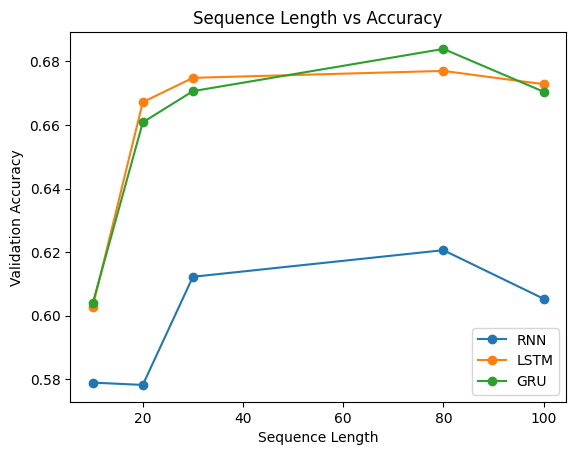

In [9]:
plt.figure()

for model_name, acc_list in results.items():
    plt.plot(seq_lengths, acc_list, marker='o', label=model_name)

plt.xlabel("Sequence Length")
plt.ylabel("Validation Accuracy")
plt.title("Sequence Length vs Accuracy")
plt.legend()

plt.show()


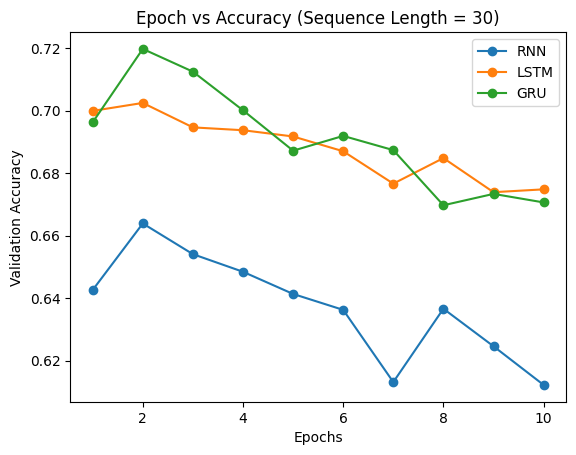

In [10]:
plt.figure()

epochs = range(1, len(epoch_results["RNN"]) + 1)

for model_name, acc_list in epoch_results.items():
    plt.plot(epochs, acc_list, marker='o', label=model_name)

plt.xlabel("Epochs")
plt.ylabel("Validation Accuracy")
plt.title(f"Epoch vs Accuracy (Sequence Length = {best_seq_len})")
plt.legend()

plt.show()


In [11]:
print("\nFinal Results:")
for model, acc in results.items():
    print(model, acc)


Final Results:
RNN [0.578966498374939, 0.5782387256622314, 0.6122634410858154, 0.6206331849098206, 0.6053493618965149]
LSTM [0.602802038192749, 0.6672125458717346, 0.6748544573783875, 0.6770378351211548, 0.6728529930114746]
GRU [0.6038937568664551, 0.6608442664146423, 0.6706695556640625, 0.6839519739151001, 0.670487642288208]
